# Tasks

In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

##### Task 1: find the y value for each x value.

The x values are [0, 2, 4, 6, 8, 10], the slope is m=5, and the y-intercept is c=3.

##### Task 2: 
- Investigate the cars dataset(check for missing values and data types)
- Identify an appropriate target for your model. Identify a few features that could be good predictors for your target
- Split the dataset into a train set and a test set. Assign the output of splitting to the variables X_train, X_test, y_train, y_test.  

In [2]:
cars = sns.load_dataset('mpg')
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
cars.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [4]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
# drop rows with missing values
cars = cars.dropna()
cars.info()


<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 30.6 KB


In [41]:
# Define the Target and Feature variables to predict mpg
#Target variable
y = cars['mpg']

#Feature variable
X = cars[['weight', 'horsepower', 'displacement', 'cylinders', 'acceleration', 'model_year']]


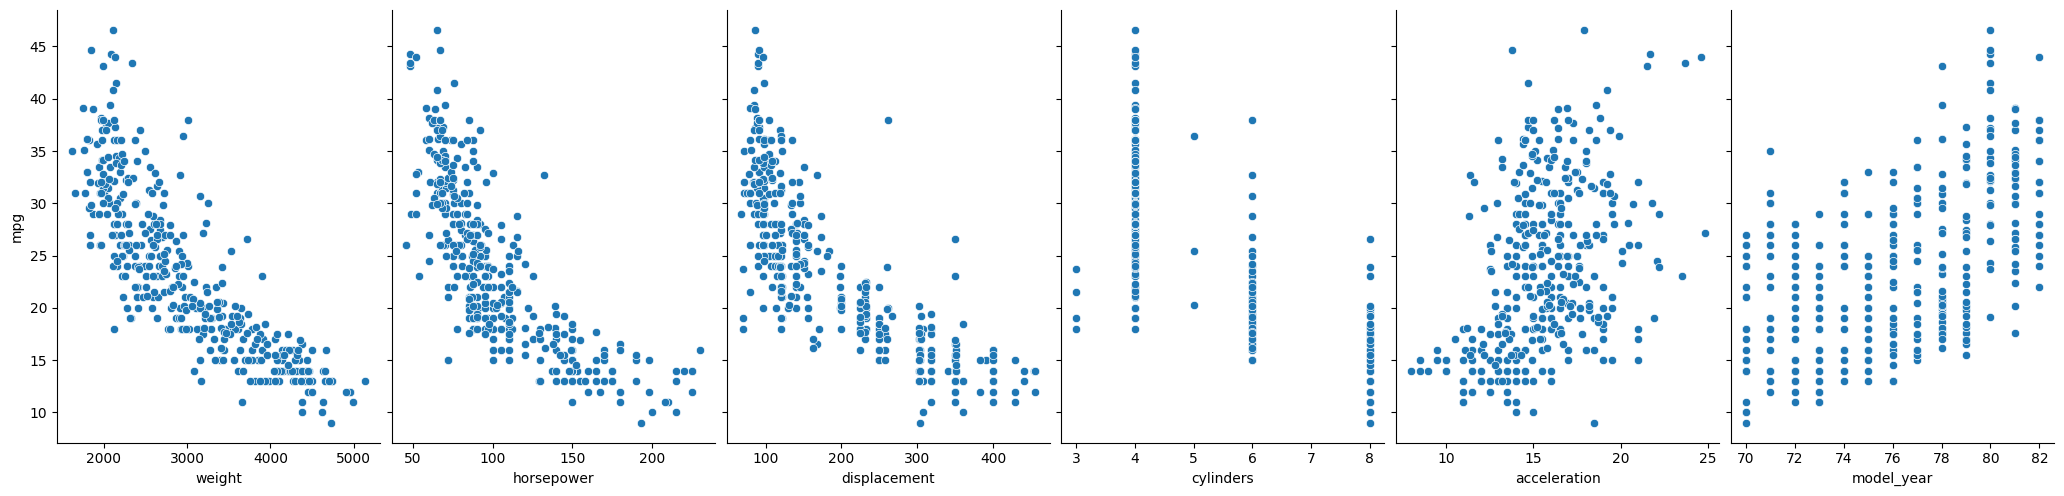

In [42]:
# Scatter each feature against the target variable
sns.pairplot(cars, x_vars=X, y_vars='mpg', height=5, aspect=0.7)
plt.show()

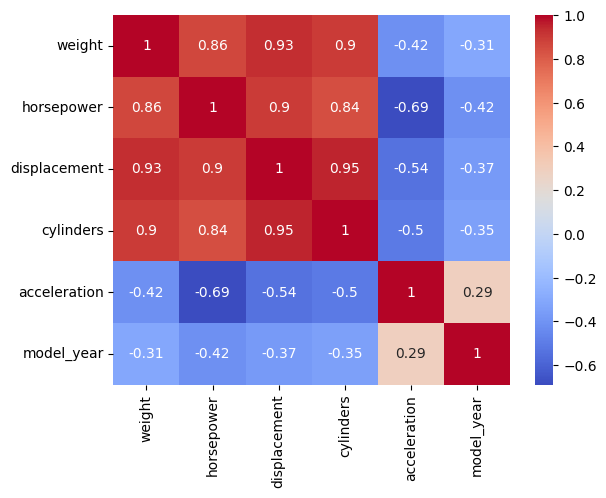

In [43]:
# View correlation matrix
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [44]:
# Pareto split data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
X_train, X_test, y_train, y_test


(     weight  horsepower  displacement  cylinders  acceleration  model_year
 167    2171        75.0          97.0          4          16.0          75
 183    2220        81.0         116.0          4          16.9          76
 147    2108        75.0          90.0          4          15.5          74
 271    2745       105.0         156.0          4          16.7          78
 159    4657       148.0         351.0          8          13.5          75
 ..      ...         ...           ...        ...           ...         ...
 213    4055       145.0         350.0          8          12.0          76
 68     4502       155.0         350.0          8          13.5          72
 25     4615       215.0         360.0          8          14.0          70
 198    1795        53.0          91.0          4          17.4          76
 177    2694        95.0         115.0          4          15.0          75
 
 [313 rows x 6 columns],
      weight  horsepower  displacement  cylinders  accelerati

In [45]:
y_train.head() 

167    29.0
183    25.0
147    24.0
271    23.2
159    14.0
Name: mpg, dtype: float64

In [46]:
y_test.head()

240    30.5
272    23.8
215    13.0
362    24.2
58     25.0
Name: mpg, dtype: float64

##### Task 3: 
- Create and train a model using the cars train and test datasets. Assign the model to a variable named car_model.

In [48]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Coefficients of the model
model.coef_

array([-0.00654748, -0.00625999,  0.00905845, -0.45394205, -0.02675486,
        0.79155508])

In [50]:
# Intercept of the model
model.intercept_

np.float64(-15.407104281064726)

In [51]:
predicted_mpg = model.predict(X_test)
predicted_mpg

array([29.40103524, 26.19021081, 18.10077977, 27.00320748, 25.77671866,
       29.22180009, 24.44412782, 25.31972016, 27.82192117, 25.13399876,
       25.3904317 , 26.76843303, 24.93261272, 15.41806914, 12.82627115,
       21.29524604, 22.68294438, 31.63261609, 25.51403725, 20.56208272,
       29.0258836 , 33.04487349, 13.93301397, 24.86814015, 24.67042348,
       22.29967032, 12.66417299, 22.49253477, 16.80910859, 34.71386328,
       34.82242331, 34.5561723 , 11.88025416,  6.43816726, 29.46168351,
       22.51488876, 27.0145583 , 27.09676507, 16.9109    , 18.13728173,
       33.35555738, 16.44210145,  8.66067702, 28.38099886, 26.59462607,
       30.33650409, 24.22657361, 34.03016728, 28.75713702, 21.1451064 ,
       30.01123676, 26.75003992, 33.7579196 , 15.38642908, 13.06388449,
       21.7555607 , 17.62658557, 29.72962408, 16.48658917, 23.45295889,
       27.99609018, 16.41088177,  8.84606727, 30.38423216, 20.85120418,
       29.00542938, 26.29544535, 30.69385996, 25.15376401, 31.02

##### Task 4: Evaluate the model based on the car dataset. Find out the R-squared, the MAE and RMSE scores. What did you notice?

In [52]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

##### Task 5: Validate the car model.
- Perform the cross validation and check for the model stability.
- Change the `cv` value to 3 for both the diamonds and cars models. What do you notice?

In [55]:
# Evaluate training data
model.score(X_train, y_train)


0.8073055947019079

In [56]:
# Evalute test data
model.score(X_test, y_test)

0.8101773729519801